# Week 6: Decision Trees and Random Forests

dataset from `Marketing_1.ipynb`. I am keeping the Week 1 work as the base and only adding the tree models here

In [1]:
import os

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Same dataset and file from Marketing_1.ipynb
cached_path = os.path.expanduser(
    "~/.cache/kagglehub/datasets/ezogngrd/"
    "synthetic-b2b-crm-and-marketing-data/versions/1"
)

if os.path.exists(cached_path):
    path = cached_path
else:
    path = kagglehub.dataset_download("ezogngrd/synthetic-b2b-crm-and-marketing-data")

df_b2b = pd.read_csv(os.path.join(path, "companies_clean_734.csv"))

df_b2b.columns = (
    df_b2b.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("(", "")
    .str.replace(")", "")
    .str.replace("%", "pct")
    .str.replace("₺", "")
)

df_b2b.head()

,company_id,industry,company_size,annual_revenue_m,marketing_spend_k,campaign_type,leads_generated,conversion_rate_pct,region,district,last_product_1,last_product_2,frequency_of_purchase,days_since_last_purchase,contract_status,total_purchases_last_year,payment_behavior,preferred_channel,sales_rep
0,C0001,"Mining, metals & minerals",Medium,17.3,33,SEM,12,0.9,Adana,Ceyhan,Process safety & automation,Valves,Monthly,6,Pending,15,On-time,Sales Rep,E**** T*******
1,C0002,Space,Small,4.9,12,Content Marketing,4,1.2,Sakarya,Arifiye,Energy storage systems,Actuators & motion control,Occasionally,310,Active,0,On-time,Sales Rep,D**** S*******
2,C0003,Buildings,Small,1.1,11,Content Marketing,9,1.1,Ankara,Etimesgut,Lighting & controls,Conduit & cable management,Quarterly,63,Active,4,Occasional delay,Sales Rep,B**** K*******
3,C0004,Oil & gas,Small,5.7,29,Trade Show,9,0.4,Eskisehir,Tepebasi,Medium-voltage power systems,Process safety & automation,Monthly,17,Active,8,On-time,Sales Rep,A**** Y*******
4,C0005,Oil & gas,Small,8.3,23,Trade Show,11,0.5,Zonguldak,Kozlu,Medium-voltage power systems,Fuel systems & emissions,Quarterly,93,Active,3,On-time,Sales Rep,C**** D*******


In [3]:
target = "annual_revenue_m"
features = [
    "marketing_spend_k",
    "leads_generated",
    "conversion_rate_pct",
    "days_since_last_purchase",
    "total_purchases_last_year",
    "company_size",
    "industry",
    "campaign_type",
    "preferred_channel",
]
data = df_b2b[[target] + features].dropna()

X = data[features]
y = data[target]

categorical_features = [
    "company_size",
    "industry",
    "campaign_type",
    "preferred_channel",
]

continuous_features = [
    "marketing_spend_k",
    "leads_generated",
    "conversion_rate_pct",
    "days_since_last_purchase",
    "total_purchases_last_year",
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("cat", encoder, categorical_features),
    ("num", "passthrough", continuous_features),
])

## Decision Trees
I am tuning `max_depth` because deeper trees can fit more detail, but they can also start memorizing the training data too much

In [4]:
def regression_scores(model_name, params, y_true, y_pred):
    return {
        "Model": model_name,
        **params,
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


results = []
tree_depths = [2, 3, 4, 5, 8, None]

for depth in tree_depths:
    tree_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(max_depth=depth, random_state=42)),
    ])

    tree_pipe.fit(X_train, y_train)
    y_pred = tree_pipe.predict(X_test)

    results.append(regression_scores(
        "Decision Tree",
        {"max_depth": depth, "n_estimators": None},
        y_test,
        y_pred,
    ))

## Random Forests

Random forests use a bunch of decision trees together instead of relying on just one tree. That usually makes the model less jumpy, so I am checking both the number of trees and the depth.

In [5]:
forest_models = {}
forest_estimators = [100, 300]
forest_depths = [3, 5, 8, None]

for n_estimators in forest_estimators:
    for depth in forest_depths:
        forest_pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=depth,
                random_state=42,
                n_jobs=-1,
            )),
        ])

        forest_pipe.fit(X_train, y_train)
        y_pred = forest_pipe.predict(X_test)

        key = (n_estimators, depth)
        forest_models[key] = forest_pipe

        results.append(regression_scores(
            "Random Forest",
            {"max_depth": depth, "n_estimators": n_estimators},
            y_test,
            y_pred,
        ))

 Results

The comparison below keeps the main regression metrics together. I am sorting by R² first, then using RMSE and MAE to see how far off the predictions are in the original revenue units.

In [6]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df.round(4)

,Model,max_depth,n_estimators,R2,RMSE,MAE
6,Random Forest,3.0,100.0,0.8441,11.9799,6.1135
8,Random Forest,8.0,100.0,0.8403,12.1246,6.0704
10,Random Forest,3.0,300.0,0.8400,12.1373,6.1364
9,Random Forest,NaN,100.0,0.8365,12.2689,6.1021
7,Random Forest,5.0,100.0,0.8358,12.2932,6.0969
12,Random Forest,8.0,300.0,0.8333,12.3884,6.1217
13,Random Forest,NaN,300.0,0.8317,12.4483,6.0915
11,Random Forest,5.0,300.0,0.8309,12.4758,6.1497
2,Decision Tree,4.0,NaN,0.8289,12.5501,6.3587
1,Decision Tree,3.0,NaN,0.8279,12.5879,6.3906


In [7]:
best_forest_row = results_df[results_df["Model"] == "Random Forest"].iloc[0]
best_depth = None if pd.isna(best_forest_row["max_depth"]) else best_forest_row["max_depth"]
best_forest_key = (int(best_forest_row["n_estimators"]), best_depth)
best_forest = forest_models[best_forest_key]

print("Best Random Forest")
print(best_forest_row)

Best Random Forest
Model           Random Forest
max_depth                 3.0
n_estimators            100.0
R2                   0.844091
RMSE                11.979945
MAE                  6.113473
Name: 6, dtype: object


The Random Forest models were the best across all. The best model used a maximum depth of 3 with 100 trees, with an R² of 0.844, an RMSE of 11.98, and an MAE of 6.11. Increasing the tree depth or the number of trees didn't improve performance showing that a relatively simple forest generalized better to the test data. The Decision Trees performed reasonably well with smaller depth, but they dropped as the trees became deeper. This pattern suggests that deeper trees were more likely to overfit the training data, while the Random Forest reduced this issue by averaging predictions for many treees.

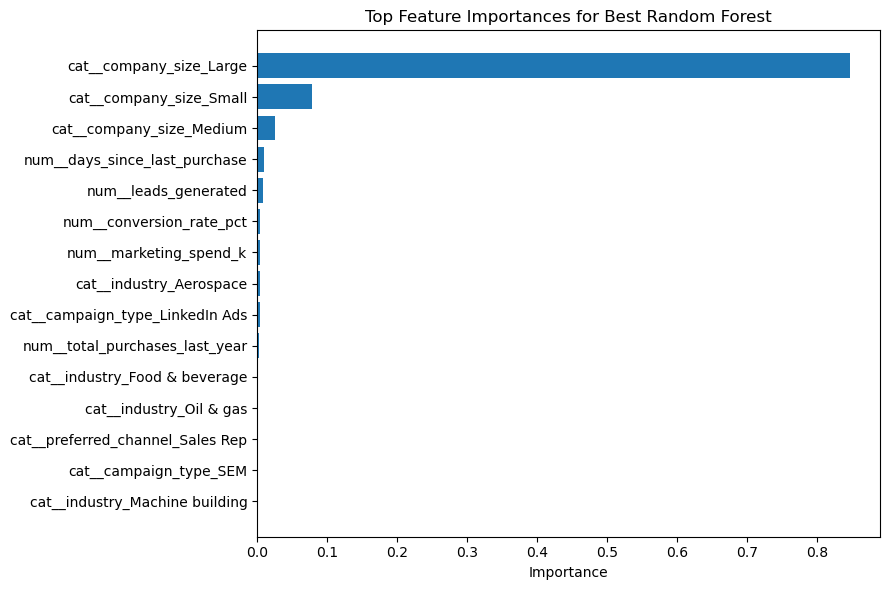

In [8]:
feature_names = best_forest.named_steps["preprocessor"].get_feature_names_out()
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_forest.named_steps["model"].feature_importances_,
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(feature_importance.head(15)["Feature"], feature_importance.head(15)["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top Feature Importances for Best Random Forest")
plt.tight_layout()
plt.show()

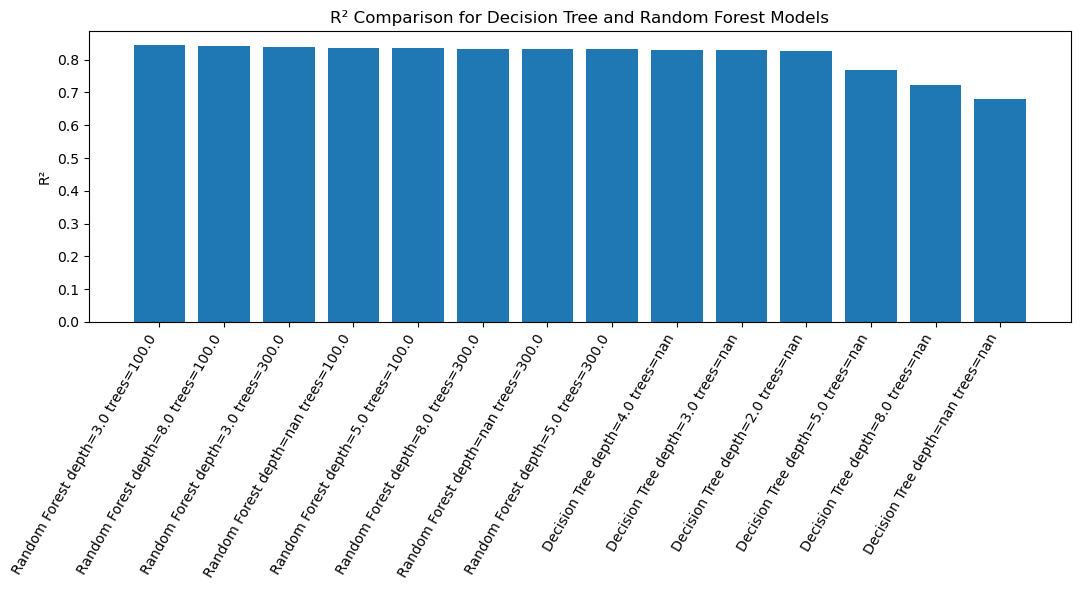

In [9]:
plot_df = results_df.copy()
plot_df["Label"] = plot_df.apply(
    lambda row: f"{row['Model']} depth={row['max_depth']} trees={row['n_estimators']}",
    axis=1,
)

plt.figure(figsize=(11, 6))
plt.bar(plot_df["Label"], plot_df["R2"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("R²")
plt.title("R² Comparison for Decision Tree and Random Forest Models")
plt.tight_layout()
plt.show()